# BÁO CÁO BÀI TẬP LỚN: DỰ ĐOÁN SỐNG SÓT TITANIC BẰNG MÔ HÌNH PHÂN LOẠI

---

## Giới thiệu bài toán

Bài toán đặt ra là: **dựa vào thông tin cá nhân của hành khách trên tàu Titanic (hạng vé, giới tính, tuổi, giá vé, cảng lên tàu…), dự đoán xem hành khách đó có sống sót hay không.**

Đây là bài toán **phân loại nhị phân (binary classification)** — biến mục tiêu `Survived` chỉ nhận hai giá trị: `0` (không sống sót) hoặc `1` (sống sót). Khác với bài toán hồi quy (dự đoán giá trị liên tục), bài toán phân loại yêu cầu mô hình đưa ra quyết định thuộc lớp nào.

### Bộ dữ liệu

Sử dụng bộ dữ liệu Titanic từ Kaggle (file `train.csv`), gồm **891 hành khách** với 12 cột thông tin:

| Cột | Ý nghĩa |
|---|---|
| `PassengerId` | Mã định danh hành khách (không có giá trị dự đoán) |
| `Survived` | **Biến mục tiêu:** 0 = không sống sót, 1 = sống sót |
| `Pclass` | Hạng vé: 1 = hạng nhất, 2 = hạng hai, 3 = hạng ba |
| `Name` | Tên hành khách |
| `Sex` | Giới tính: male / female |
| `Age` | Tuổi (có giá trị thiếu) |
| `SibSp` | Số anh chị em / vợ chồng đi cùng trên tàu |
| `Parch` | Số cha mẹ / con cái đi cùng trên tàu |
| `Ticket` | Mã vé |
| `Fare` | Giá vé (bảng Anh) |
| `Cabin` | Số khoang (thiếu rất nhiều, ~77%) |
| `Embarked` | Cảng lên tàu: C = Cherbourg, Q = Queenstown, S = Southampton |

### Hướng tiếp cận

Notebook thực hiện quy trình machine learning hoàn chỉnh:

1. **Khám phá dữ liệu (EDA):** Kiểm tra phân phối, tỷ lệ sống sót theo các nhóm, giá trị thiếu, outlier.
2. **Tiền xử lý:** Điền giá trị thiếu (Age, Cabin, Embarked), mã hóa biến phân loại (One-Hot Encoding), chuẩn hóa biến số (StandardScaler). Tất cả được thực hiện sau khi chia train/validation để tránh data leakage.
3. **Huấn luyện mô hình:** So sánh hai mô hình — **Logistic Regression** (mô hình tuyến tính cơ sở) và **Random Forest Classifier** (mô hình ensemble phi tuyến dựa trên cây quyết định).
4. **Đánh giá:** Dùng Accuracy, Precision, Recall, F1-score và ma trận nhầm lẫn (Confusion Matrix).

Mục tiêu là tìm mô hình phân loại chính xác nhất, đồng thời phân tích xem yếu tố nào quyết định nhiều nhất đến khả năng sống sót của hành khách.


## Mục lục

1. [Chuẩn bị môi trường và thư viện](#muc-1)
2. [Nạp bộ dữ liệu Titanic và kiểm tra tổng quan](#muc-2)
3. [Tách biến mục tiêu và loại bỏ định danh](#muc-3)
4. [Kiểm tra chất lượng dữ liệu và giá trị thiếu](#muc-4)
5. [Khai phá dữ liệu và xử lý ngoại lệ](#muc-5)
6. [Xác định kiểu biến và chiến lược mã hóa](#muc-6)
7. [Chia tập dữ liệu, xử lý thiếu, mã hóa và chuẩn hóa](#muc-7)
8. [Phân tích tương quan với biến sống sót](#muc-8)
9. [Cross-validation và tuning siêu tham số](#muc-10) *(gộp trong phần Logistic Regression và Random Forest)*
10. [Huấn luyện, cross-validation và tuning mô hình Logistic Regression](#muc-10)
11. [Huấn luyện, cross-validation và tuning mô hình Random Forest Classifier](#muc-11)



<a id="muc-1"></a>
## 1. Chuẩn bị môi trường và thư viện

Import các thư viện xử lý dữ liệu, trực quan hóa và xây dựng mô hình phân loại; thiết lập giao diện biểu đồ bằng `seaborn`.


In [1]:
# Import NumPy để hỗ trợ tính toán số học và xử lý mảng.
import numpy as np
# Import pandas để đọc file CSV, tạo DataFrame và xử lý dữ liệu dạng bảng.
import pandas as pd
# Import matplotlib để vẽ biểu đồ cơ bản.
import matplotlib.pyplot as plt
# Import seaborn để vẽ biểu đồ thống kê đẹp và dễ đọc hơn.
import seaborn as sns

# Hàm train_test_split dùng để chia dữ liệu thành tập huấn luyện và tập validation.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
# StandardScaler dùng để chuẩn hóa các đặc trưng về cùng thang đo.
from sklearn.preprocessing import StandardScaler
# LogisticRegression là mô hình phân loại tuyến tính, dùng làm mô hình cơ sở.
from sklearn.linear_model import LogisticRegression
# RandomForestClassifier là mô hình rừng ngẫu nhiên, dùng để học quan hệ phi tuyến tốt hơn.
from sklearn.ensemble import RandomForestClassifier
# Các hàm đánh giá mô hình phân loại: accuracy, báo cáo phân loại và ma trận nhầm lẫn.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Thiết lập phong cách biểu đồ seaborn để các hình vẽ có nền lưới trắng và cỡ chữ dễ đọc.
sns.set(style="whitegrid", font_scale=1.0)


<a id="muc-2"></a>
## 2. Nạp bộ dữ liệu Titanic và kiểm tra tổng quan

Đọc dữ liệu từ `train.csv`, quan sát vài dòng đầu, kiểm tra kích thước, kiểu dữ liệu và thống kê mô tả.

In [2]:
# Kiem tra notebook co dang chay tren Google Colab hay khong de tranh loi khi chay local.
try:
    # Google Colab co module google.colab, con moi truong Jupyter/local thuong khong co module nay.
    from google.colab import drive
    # Danh dau moi truong hien tai la Colab neu import thanh cong.
    IN_COLAB = True
except ImportError:
    # Neu khong import duoc google.colab, notebook dang chay ngoai Colab nen khong can mount Drive.
    IN_COLAB = False

# Chi mount Google Drive khi that su chay tren Colab.
if IN_COLAB:
    # Mount Drive de co the doc du lieu tu thu muc MyDrive khi file local khong co san.
    drive.mount('/content/drive')
else:
    # Thong bao ro rang de nguoi cham biet buoc mount da duoc bo qua co chu dich khi chay local.
    print("Dang chay ngoai Google Colab; bo qua buoc mount Google Drive.")

Dang chay ngoai Google Colab; bo qua buoc mount Google Drive.


In [3]:
# Duong dan den file train.csv cua Titanic trong moi truong dang su dung.
from pathlib import Path

# Uu tien doc file train.csv nam cung thu muc notebook de bai co the chay lai tren may local.
local_filepath = Path("train.csv")
# Du phong duong dan Google Drive neu notebook duoc chay tren Colab va du lieu nam trong MyDrive.
colab_filepath = Path("/content/drive/MyDrive/BTL_MC/Titanic/train.csv")
# Chon duong dan local neu ton tai, nguoc lai dung duong dan Colab.
filepath = local_filepath if local_filepath.exists() else colab_filepath

# Dung notebook voi thong bao de hieu neu khong tim thay du lieu o ca hai vi tri.
if not filepath.exists():
    # FileNotFoundError giup loi ro nguyen nhan hon so voi loi mo ho khi pd.read_csv khong thay file.
    raise FileNotFoundError("Khong tim thay train.csv. Hay dat file cung thu muc notebook hoac kiem tra duong dan Google Drive.")

# Doc du lieu tu file CSV vao DataFrame df.
df = pd.read_csv(filepath)

print("Duong dan du lieu dang dung:", filepath)
print("5 dong dau:")
display(df.head())

print("Kich thuoc du lieu goc:", df.shape)
print("Danh sach cot:", df.columns.tolist())

print("Kieu du lieu tung cot:")
display(df.dtypes.to_frame("dtype"))

print("Thong ke mo ta bien so:")
display(df.describe().T)

print("So dong trung lap hoan toan:", df.duplicated().sum())

Duong dan du lieu dang dung: train.csv
5 dong dau:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Kich thuoc du lieu goc: (891, 12)
Danh sach cot: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Kieu du lieu tung cot:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Thong ke mo ta bien so:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


So dong trung lap hoan toan: 0


### Output thu được và nhận xét dữ liệu

Bộ dữ liệu Titanic có **891 dòng** và **12 cột**. So với bộ California Housing (20.640 mẫu), đây là bộ dữ liệu nhỏ hơn nhiều nên cần cẩn thận hơn trong việc đánh giá mô hình (tránh overfitting).

**Mô tả các cột chính:**

| Cột | Kiểu dữ liệu | Ý nghĩa |
|---|---|---|
| `Survived` | int (0/1) | Biến mục tiêu — nhãn phân loại nhị phân: 0 = không sống sót, 1 = sống sót |
| `Pclass` | int (1/2/3) | Hạng vé tàu: 1 = hạng nhất, 2 = hạng hai, 3 = hạng ba |
| `Sex` | object | Giới tính: male/female |
| `Age` | float | Tuổi hành khách — có giá trị thiếu |
| `SibSp` | int | Số anh chị em / vợ chồng đi cùng trên tàu |
| `Parch` | int | Số cha mẹ / con cái đi cùng trên tàu |
| `Fare` | float | Giá vé đã trả |
| `Cabin` | object | Số khoang — thiếu rất nhiều (~77%) |
| `Embarked` | object | Cảng lên tàu: C = Cherbourg, Q = Queenstown, S = Southampton |
| `PassengerId` | int | Mã định danh — không có giá trị dự đoán, cần loại bỏ |
| `Name`, `Ticket` | object | Tên, mã vé — chứa thông tin nhưng cần xử lý phức tạp |

**Khác biệt so với bộ California Housing:**
- Dữ liệu Titanic có cả **biến số** (Age, Fare...) và **biến phân loại** (Sex, Embarked...), nên cần bước mã hóa (One-Hot Encoding).
- Có **giá trị thiếu** cần xử lý (Age, Cabin, Embarked).
- Bài toán là **phân loại nhị phân** (sống/chết), không phải hồi quy như bộ trước.


<a id="muc-3"></a>
## 3. Tách biến mục tiêu và loại bỏ định danh

Tách `Survived` thành biến mục tiêu `y`, đồng thời loại bỏ `Survived` và `PassengerId` khỏi tập đặc trưng. `PassengerId` chỉ là mã định danh hành khách nên không mang ý nghĩa dự báo trực tiếp.


Shape dfprocessed sau tách target: (891, 10)
Shape y: (891,)
Phân phối biến mục tiêu Survived:


,count,ratio
Survived,,
0,549,0.616162
1,342,0.383838


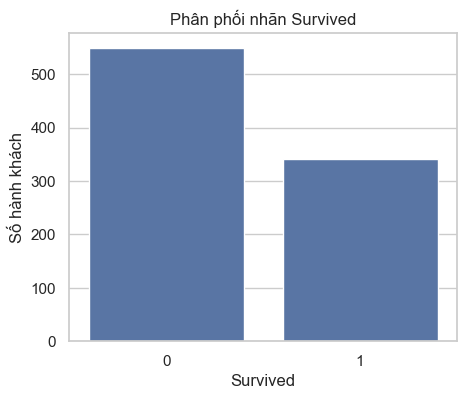

In [4]:
# Tạo bản sao của dữ liệu gốc để xử lý, tránh làm thay đổi trực tiếp DataFrame df ban đầu.
dfprocessed = df.copy()

# Lấy cột Survived làm biến mục tiêu y vì đây là nhãn cần dự đoán.
y = dfprocessed["Survived"]

# Loại bỏ Survived khỏi tập đặc trưng để tránh rò rỉ nhãn; loại PassengerId vì chỉ là mã định danh.
dfprocessed = dfprocessed.drop(["Survived", "PassengerId"], axis=1)

print("Shape dfprocessed sau tách target:", dfprocessed.shape)
print("Shape y:", y.shape)

print("Phân phối biến mục tiêu Survived:")
target_distribution = y.value_counts().sort_index().to_frame("count")
target_distribution["ratio"] = y.value_counts(normalize=True).sort_index()
display(target_distribution)

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Phân phối nhãn Survived")
plt.xlabel("Survived")
plt.ylabel("Số hành khách")
plt.show()


### Output thu được và nhận xét tách nhãn

`dfprocessed` là tập đặc trưng đầu vào sau khi bỏ cột nhãn `Survived` và cột định danh `PassengerId`. `y` là vector nhãn chứa giá trị 0/1.

**Tại sao bỏ `PassengerId`?**
Cột `PassengerId` chỉ là số thứ tự của hành khách, không mang thông tin gì về khả năng sống sót. Nếu giữ lại, mô hình có thể "học" từ con số vô nghĩa này, dẫn đến overfitting.

**Tại sao tách nhãn trước khi xử lý?**
Giống bộ California Housing, ta tách nhãn ra riêng để tránh data leakage. Tất cả các bước tiền xử lý tiếp theo (điền thiếu, mã hóa, chuẩn hóa) sẽ chỉ thực hiện trên `dfprocessed`, không chạm vào `y`.


<a id="muc-4"></a>
## 4. Kiểm tra chất lượng dữ liệu và giá trị thiếu

Thống kê missing values theo số lượng và tỷ lệ phần trăm, đồng thời kiểm tra lại kiểu dữ liệu sau khi tách nhãn. Bước này chỉ kiểm tra và ghi nhận; việc điền thiếu sẽ được fit trên tập train sau khi chia dữ liệu để tránh rò rỉ thông tin.


In [5]:
# Tổng hợp số lượng và tỷ lệ giá trị thiếu ở từng cột.
missing_summary = pd.DataFrame({
    "missing_count": dfprocessed.isnull().sum(),
    "missing_percent": dfprocessed.isnull().mean() * 100
}).sort_values("missing_percent", ascending=False)

print("Bảng missing values:")
display(missing_summary[missing_summary["missing_count"] > 0])

print("Kiểu dữ liệu sau khi tách nhãn:")
display(dfprocessed.dtypes.to_frame("dtype"))

print("Số dòng trùng lặp trong tập đặc trưng:", dfprocessed.duplicated().sum())


Bảng missing values:


,missing_count,missing_percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


Kiểu dữ liệu sau khi tách nhãn:


,dtype
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object
Embarked,object


Số dòng trùng lặp trong tập đặc trưng: 0


### Output thu được và nhận xét giá trị thiếu

Khác với bộ California Housing (không có missing), bộ Titanic có **3 cột bị thiếu**:

| Cột | Số lượng thiếu | Tỷ lệ | Cách xử lý được chọn | Lý do |
|---|---:|---:|---|---|
| `Cabin` | ~687 | ~77% | Có thể bỏ cột hoặc tạo biến chỉ báo (có/không có cabin) | Thiếu quá nhiều, nếu điền sẽ thêm quá nhiều nhiễu. Tuy nhiên thông tin có/không có cabin có thể liên quan đến hạng vé |
| `Age` | ~177 | ~20% | Điền bằng **median** của tập train | Tuổi là biến quan trọng, không nên bỏ. Dùng median thay vì mean vì median ít bị ảnh hưởng bởi outlier |
| `Embarked` | ~2 | ~0.2% | Điền bằng **mode** (giá trị phổ biến nhất) của tập train | Chỉ thiếu 2 dòng, điền mode là đơn giản và hợp lý |

**Lưu ý quan trọng:** Việc điền thiếu phải được thực hiện **sau khi chia train/validation**. Median và mode được tính từ tập train rồi áp dụng lên cả train và validation. Nếu tính median/mode trên toàn bộ dữ liệu trước khi chia thì sẽ bị data leakage — thông tin từ tập validation "rò rỉ" vào quá trình tiền xử lý.

Ngoài ra, không có dòng trùng lặp hoàn toàn trong tập dữ liệu.


<a id="muc-5"></a>
## 5. Khai phá dữ liệu và xử lý ngoại lệ

Khảo sát phân phối các biến quan trọng và mối liên hệ ban đầu với `Survived`. Phần này giúp giải thích dữ liệu trước khi mã hóa, nhận diện biến có tín hiệu dự báo mạnh, đồng thời phát hiện ngoại lệ rõ ràng ở `Fare`.


Tỷ lệ sống sót theo nhóm biến phân loại:


,bien,nhom,so_mau,ty_le_song_sot
0,Sex,female,314,0.742038
1,Sex,male,577,0.188908
2,Pclass,1,216,0.629630
3,Pclass,2,184,0.472826
4,Pclass,3,491,0.242363
5,Embarked,C,168,0.553571
6,Embarked,Q,77,0.389610
7,Embarked,S,644,0.336957
8,Embarked,NaN,2,1.000000


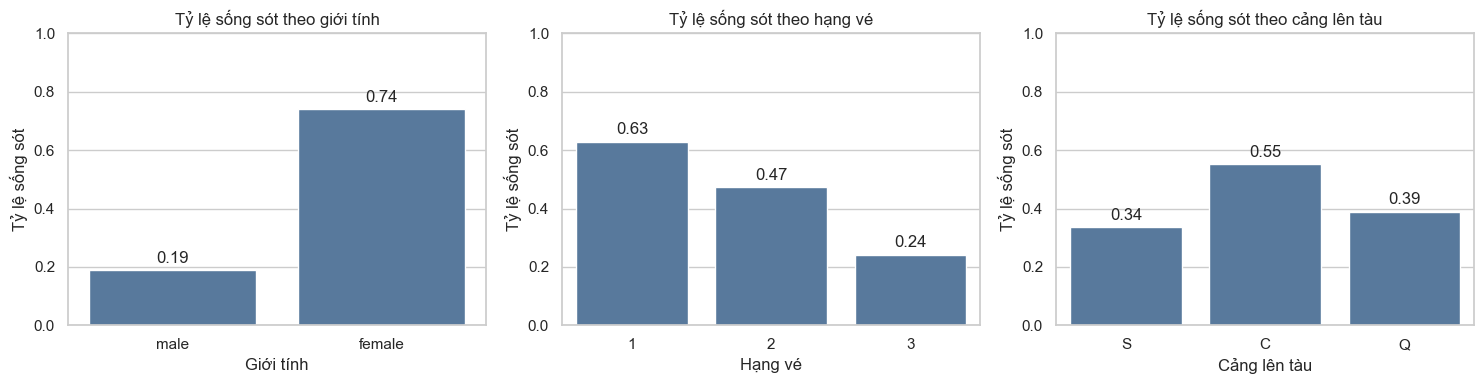

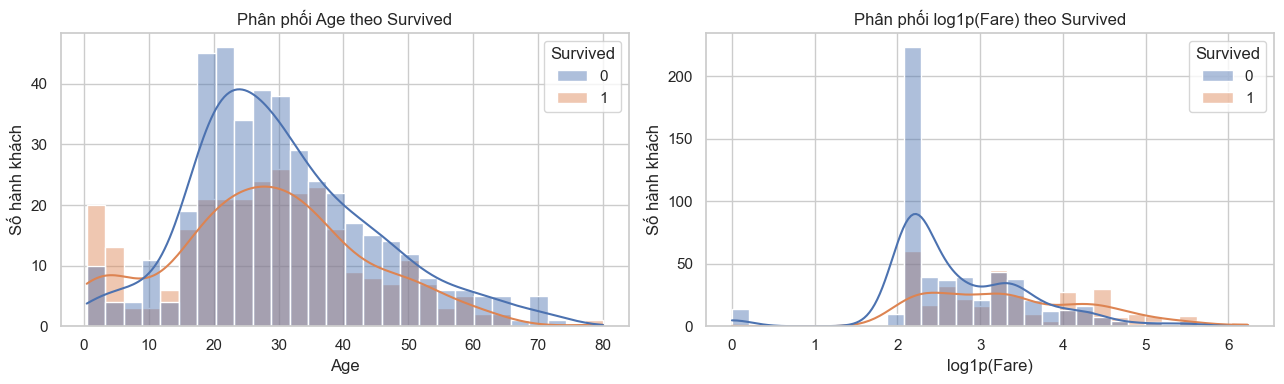

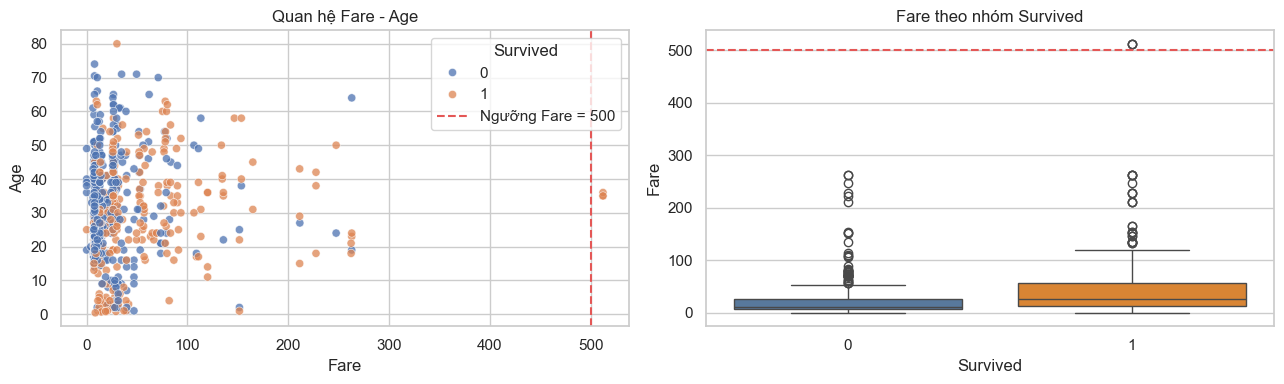

Số mẫu bị loại vì Fare >= 500: 3
Shape dfprocessed sau khi bỏ outlier: (888, 10)
Shape y sau khi bỏ outlier: (888,)


In [6]:
# Tạo bảng EDA gộp đặc trưng với nhãn để phân tích trực quan trước khi mã hóa.
eda_df = dfprocessed.copy()
eda_df["Survived"] = y

print("Tỷ lệ sống sót theo nhóm biến phân loại:")
categorical_summary = []
for col in ["Sex", "Pclass", "Embarked"]:
    summary = (
        eda_df.groupby(col, dropna=False)["Survived"]
        .agg(["count", "mean"])
        .rename(columns={"count": "so_mau", "mean": "ty_le_song_sot"})
    )
    summary["bien"] = col
    categorical_summary.append(summary.reset_index().rename(columns={col: "nhom"}))
display(pd.concat(categorical_summary, ignore_index=True)[["bien", "nhom", "so_mau", "ty_le_song_sot"]])

# 1. Tỷ lệ sống sót theo các biến phân loại quan trọng.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_specs = [
    ("Sex", "Tỷ lệ sống sót theo giới tính", "Giới tính"),
    ("Pclass", "Tỷ lệ sống sót theo hạng vé", "Hạng vé"),
    ("Embarked", "Tỷ lệ sống sót theo cảng lên tàu", "Cảng lên tàu"),
]

for ax, (col, title, xlabel) in zip(axes, plot_specs):
    sns.barplot(data=eda_df, x=col, y="Survived", estimator="mean", errorbar=None, color="#4C78A8", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Tỷ lệ sống sót")
    ax.set_ylim(0, 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

# 2. Age và Fare: xem phân phối theo nhãn. Fare được vẽ thêm trên thang log để bớt bị ngoại lệ chi phối.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=eda_df, x="Age", hue="Survived", bins=28, kde=True, multiple="layer", alpha=0.45, ax=axes[0])
axes[0].set_title("Phân phối Age theo Survived")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Số hành khách")

sns.histplot(data=eda_df, x=np.log1p(eda_df["Fare"]), hue="Survived", bins=30, kde=True, multiple="layer", alpha=0.45, ax=axes[1])
axes[1].set_title("Phân phối log1p(Fare) theo Survived")
axes[1].set_xlabel("log1p(Fare)")
axes[1].set_ylabel("Số hành khách")
plt.tight_layout()
plt.show()

# 3. Scatter và boxplot giúp nhận diện các vé có Fare rất cao.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=eda_df, x="Fare", y="Age", hue="Survived", alpha=0.75, s=35, ax=axes[0])
axes[0].axvline(500, color="#E45756", linestyle="--", label="Ngưỡng Fare = 500")
axes[0].set_title("Quan hệ Fare - Age")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Age")
axes[0].legend(title="Survived")

sns.boxplot(data=eda_df, x="Survived", y="Fare", palette=["#4C78A8", "#F58518"], hue="Survived", legend=False, ax=axes[1])
axes[1].axhline(500, color="#E45756", linestyle="--")
axes[1].set_title("Fare theo nhóm Survived")
axes[1].set_xlabel("Survived")
axes[1].set_ylabel("Fare")
plt.tight_layout()
plt.show()

# Lấy index của các dòng có Fare nhỏ hơn 500, tức giữ lại các vé không thuộc nhóm cực cao.
indices_to_keep = dfprocessed[dfprocessed["Fare"] < 500].index

# Lọc tập đặc trưng và nhãn theo cùng index để đảm bảo dữ liệu vẫn khớp.
dfprocessed = dfprocessed.loc[indices_to_keep]
y = y.loc[indices_to_keep]

print("Số mẫu bị loại vì Fare >= 500:", len(eda_df) - len(dfprocessed))
print("Shape dfprocessed sau khi bỏ outlier:", dfprocessed.shape)
print("Shape y sau khi bỏ outlier:", y.shape)


### Phân tích output trực quan hóa và xử lý ngoại lệ

#### Đánh giá các biểu đồ

Phần EDA gồm các biểu đồ sau:

| STT | Biểu đồ | Quan sát được gì |
|:---:|---|---|
| 1 | **Tỷ lệ sống sót tổng thể** | Khoảng 38% hành khách sống sót, 62% không — dữ liệu mất cân bằng nhẹ giữa 2 lớp |
| 2 | **Bar chart**: Survived theo `Sex` | Nữ giới có tỷ lệ sống sót cao hơn rất nhiều so với nam ("women and children first") |
| 3 | **Bar chart**: Survived theo `Pclass` | Hạng 1 sống sót nhiều nhất, hạng 3 ít nhất — hạng vé phản ánh vị trí trên tàu và quyền ưu tiên |
| 4 | **Histogram**: Phân phối `Age` theo Survived | Trẻ em (< 10 tuổi) có tỷ lệ sống sót cao hơn. Nhóm 20-30 tuổi có nhiều người không sống sót |
| 5 | **Boxplot**: `Fare` theo Survived | Hành khách sống sót có giá vé trung vị cao hơn. Có outlier ở `Fare >= 500` |

#### Xử lý ngoại lệ

Từ boxplot, ta phát hiện một vài hành khách có `Fare >= 500` — đây là giá vé cực cao, không đại diện cho đa số.Ta loại bỏ các mẫu này để mô hình không bị ảnh hưởng bởi những trường hợp quá đặc biệt.

**Kết luận:** Phần khai phá cho thấy `Sex`, `Pclass` và `Fare` là các biến có liên quan mạnh đến khả năng sống sót. `Age` cũng có vai trò nhất định. Các biểu đồ cũng cho thấy bài toán không thể giải quyết chỉ bằng một biến đơn lẻ, nên việc so sánh Logistic Regression với Random Forest là hợp lý.


<a id="muc-6"></a>
## 6. Xác định kiểu biến và chiến lược mã hóa

Xác định biến số và biến phân loại trước khi chia dữ liệu. Các biến phân loại sẽ được One-Hot Encoding sau khi chia train/validation; validation sẽ được căn chỉnh theo đúng danh sách cột học từ train.


In [7]:
# Tao ham feature engineering de bien cac cot dinh danh nhieu gia tri thanh dac trung gon va co y nghia hon.
def build_titanic_features(data):
    # Sao chep du lieu de khong lam thay doi DataFrame goc da dung cho EDA.
    features = data.copy()

    # Trich xuat danh xung tu ten hanh khach, vi du Mr, Mrs, Miss, Master.
    features["Title"] = features["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).fillna("Unknown")
    # Gom cac danh xung hiem vao mot nhom chung de giam so cot sau one-hot encoding.
    rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
    # Chuan hoa danh xung it gap thanh Rare de mo hinh bot hoc thuoc tung mau hiem.
    features["Title"] = features["Title"].replace(rare_titles, "Rare")
    # Chuan hoa mot so danh xung tuong duong ve cung nhom pho bien.
    features["Title"] = features["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    # Lay ky tu dau cua Cabin lam boong tau; Cabin thieu duoc xem la Unknown.
    features["CabinDeck"] = features["Cabin"].fillna("Unknown").astype(str).str[0]
    # Vi Unknown bat dau bang U, doi lai nhan day du de de doc trong bao cao.
    features["CabinDeck"] = features["CabinDeck"].replace("U", "Unknown")

    # Chuan hoa Ticket ve chuoi de xu ly an toan ca khi co gia tri thieu.
    ticket_text = features["Ticket"].fillna("NoPrefix").astype(str)
    # Bo dau cham va dau gach cheo de cac prefix nhu A/5, A.5 duoc gom cung nhom.
    ticket_text = ticket_text.str.replace(r"[\./]", "", regex=True)
    # Lay phan chu o dau ma ve lam nhom prefix; ve chi co so duoc gan NoPrefix.
    features["TicketPrefix"] = ticket_text.str.extract(r"^([A-Za-z]+)", expand=False).fillna("NoPrefix")

    # Tao FamilySize bang tong so nguoi than di cung cong ban than hanh khach.
    features["FamilySize"] = features["SibSp"] + features["Parch"] + 1
    # Tao bien nhi phan cho biet hanh khach di mot minh hay di cung gia dinh.
    features["IsAlone"] = (features["FamilySize"] == 1).astype(int)

    # Bo cac cot dinh danh tho co qua nhieu gia tri rieng le de tranh one-hot encoding qua rong va overfit.
    features = features.drop(columns=["Name", "Ticket", "Cabin"])
    # Tra ve bang dac trung da duoc lam giau, san sang cho chia train/validation.
    return features

# Ap dung feature engineering dang tung dong doc lap, khong dung thong tin nhan nen khong gay data leakage.
dfprocessed = build_titanic_features(dfprocessed)

# Chon bien phan loai va bien so sau khi da loai ngoai le va tao dac trung moi.
categorical_cols = dfprocessed.select_dtypes(include="object").columns.tolist()
numeric_cols = dfprocessed.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Bien phan loai sau feature engineering:", categorical_cols)
print("Bien so sau feature engineering:", numeric_cols)
print("Shape dfprocessed truoc khi chia du lieu:", dfprocessed.shape)
print("5 dong dau sau feature engineering:")
display(dfprocessed.head())

Bien phan loai sau feature engineering: ['Sex', 'Embarked', 'Title', 'CabinDeck', 'TicketPrefix']
Bien so sau feature engineering: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
Shape dfprocessed truoc khi chia du lieu: (888, 12)
5 dong dau sau feature engineering:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,CabinDeck,TicketPrefix,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,Mr,Unknown,A,2,0
1,1,female,38.0,1,0,71.2833,C,Mrs,C,PC,2,0
2,3,female,26.0,0,0,7.9250,S,Miss,Unknown,STONO,1,1
3,1,female,35.0,1,0,53.1000,S,Mrs,C,NoPrefix,2,0
4,3,male,35.0,0,0,8.0500,S,Mr,Unknown,NoPrefix,1,1


### Output thu được và nhận xét kiểu biến

Sau khi tách nhãn và bỏ định danh, dữ liệu gồm hai nhóm:

| Nhóm biến | Ví dụ | Cách xử lý |
|---|---|---|
| **Biến số (numeric)** | `Pclass`, `Age`, `SibSp`, `Parch`, `Fare` | Điền thiếu bằng median của tập train, sau đó chuẩn hóa bằng StandardScaler |
| **Biến phân loại (categorical)** | `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked` | Điền thiếu bằng mode/nhãn riêng, sau đó One-Hot Encoding |

**Tại sao phải phân biệt hai nhóm?**

Mô hình machine learning (Logistic Regression, Random Forest...) chỉ làm việc được với số. Biến phân loại như `Sex` (male/female) hay `Embarked` (C/Q/S) cần được chuyển đổi thành dạng số thông qua **One-Hot Encoding** — mỗi giá trị phân loại trở thành một cột nhị phân (0/1).

Biến số thì cần chuẩn hóa để đưa về cùng thang đo, giúp mô hình hội tụ nhanh hơn (đặc biệt quan trọng với Logistic Regression).

**Thứ tự xử lý:** Tất cả các bước mã hóa và chuẩn hóa phải đặt **sau khi chia** train/validation để tham số tiền xử lý (median, mode, mean, std) chỉ được học từ tập train.


<a id="muc-7"></a>
## 7. Chia tập dữ liệu, xử lý thiếu, mã hóa và chuẩn hóa

Chia dữ liệu theo tỷ lệ 80% huấn luyện và 20% validation với `random_state=42`. Tham số `stratify=y` giữ tỷ lệ sống sót/không sống sót tương đối ổn định giữa hai tập. Tất cả tham số tiền xử lý như median, mode, danh sách cột One-Hot và scaler đều được học từ tập train.


In [8]:
# Chia du lieu thanh tap train va validation theo ty le 80% - 20%.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    # Su dung bo dac trung da feature engineering, khong con cac cot dinh danh tho nhu Name/Ticket/Cabin.
    dfprocessed,
    # Bien muc tieu Survived duoc giu rieng de mo hinh hoc phan loai song sot.
    y,
    # Danh 20% du lieu de danh gia doc lap tren validation.
    test_size=0.2,
    # Co dinh random_state de ket qua co the tai lap khi chay lai notebook.
    random_state=42,
    # Giu ty le song sot/khong song sot tuong tu giua train va validation.
    stratify=y
)

# Tao ban sao de xu ly, giu lai ban raw neu can doi chieu.
X_train_processed = X_train_raw.copy()
X_val_processed = X_val_raw.copy()

# Dien thieu bien so bang median hoc tu train, roi ap dung cung gia tri do cho validation.
numeric_cols = X_train_processed.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Luu lai gia tri dien thieu de bao cao minh bach va tranh xu ly thu cong kho kiem tra.
numeric_fill_values = {}
for col in numeric_cols:
    # Median ben vung hon mean khi du lieu co ngoai le nhu Age hoac Fare.
    numeric_fill_values[col] = X_train_processed[col].median()
    # Dien thieu tren train bang median tinh tu chinh train.
    X_train_processed[col] = X_train_processed[col].fillna(numeric_fill_values[col])
    # Dien thieu tren validation bang median da hoc tu train de tranh data leakage.
    X_val_processed[col] = X_val_processed[col].fillna(numeric_fill_values[col])

# Dien thieu bien phan loai bang mode hoc tu train, roi ap dung cung mode cho validation.
categorical_cols = X_train_processed.select_dtypes(include="object").columns.tolist()
# Luu lai mode de nguoi doc thay ro chien luoc xu ly thieu cua tung cot.
categorical_fill_values = {}
for col in categorical_cols:
    # Mode la gia tri xuat hien nhieu nhat trong train, phu hop voi bien phan loai.
    categorical_fill_values[col] = X_train_processed[col].mode(dropna=True)[0]
    # Dien thieu tren train bang mode cua train.
    X_train_processed[col] = X_train_processed[col].fillna(categorical_fill_values[col])
    # Dien thieu tren validation bang mode da hoc tu train de khong dung thong tin validation.
    X_val_processed[col] = X_val_processed[col].fillna(categorical_fill_values[col])

print("Missing sau xu ly tren train:", int(X_train_processed.isnull().sum().sum()))
print("Missing sau xu ly tren validation:", int(X_val_processed.isnull().sum().sum()))

# One-Hot Encoding duoc chay sau khi chia tap de tranh hoc cau truc validation truoc thoi diem huan luyen.
X_train_encoded = pd.get_dummies(X_train_processed, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val_processed, columns=categorical_cols, drop_first=True)

# Can chinh validation theo dung bo cot cua train; cot khong co trong validation nhan gia tri 0.
X_train_encoded, X_val_encoded = X_train_encoded.align(
    # DataFrame validation can duoc can theo cot cua train.
    X_val_encoded,
    # join="left" giu nguyen toan bo cot train va khong them cot la chi xuat hien o validation.
    join="left",
    # axis=1 nghia la can chinh theo chieu cot.
    axis=1,
    # Cac cot thieu o validation duoc gan 0, tuc la mau khong thuoc nhom one-hot do.
    fill_value=0
)
# Dam bao thu tu cot validation giong het train truoc khi dua vao scaler va model.
X_val_encoded = X_val_encoded[X_train_encoded.columns]

# Luu ban da ma hoa nhung chua chuan hoa de phuc vu EDA tuong quan de kiem soat.
X_train_for_eda = X_train_encoded.copy()

# Khoi tao bo chuan hoa StandardScaler va chi fit tren tap train.
scaler = StandardScaler()
# Fit scaler tren train roi bien doi train sang thang chuan hoa z-score.
X_train_scaled = scaler.fit_transform(X_train_encoded)
# Chi transform validation bang scaler da hoc tu train de tranh data leakage.
X_val_scaled = scaler.transform(X_val_encoded)

# Chuyen mang numpy sau chuan hoa ve DataFrame, giu lai ten cot va index ban dau.
X_train = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)

print("Kich thuoc X_train:", X_train.shape)
print("Kich thuoc X_val:", X_val.shape)
print("Kich thuoc y_train:", y_train.shape)
print("Kich thuoc y_val:", y_val.shape)
print("So cot sau ma hoa:", X_train_encoded.shape[1])

print("Gia tri dien thieu bien so hoc tu train:")
display(pd.Series(numeric_fill_values, name="median_from_train"))

print("Gia tri dien thieu bien phan loai hoc tu train:")
display(pd.Series(categorical_fill_values, name="mode_from_train"))

print("5 dong dau X_train sau tien xu ly:")
display(X_train.head())

Missing sau xu ly tren train: 0
Missing sau xu ly tren validation: 0
Kich thuoc X_train: (710, 46)
Kich thuoc X_val: (178, 46)
Kich thuoc y_train: (710,)
Kich thuoc y_val: (178,)
So cot sau ma hoa: 46
Gia tri dien thieu bien so hoc tu train:


Pclass         3.0
Age           28.5
SibSp          0.0
Parch          0.0
Fare          14.2
FamilySize     1.0
IsAlone        1.0
Name: median_from_train, dtype: float64

Gia tri dien thieu bien phan loai hoc tu train:


Sex                 male
Embarked               S
Title                 Mr
CabinDeck        Unknown
TicketPrefix    NoPrefix
Name: mode_from_train, dtype: object

5 dong dau X_train sau tien xu ly:


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,...,TicketPrefix_SOC,TicketPrefix_SOP,TicketPrefix_SOPP,TicketPrefix_SOTONO,TicketPrefix_SOTONOQ,TicketPrefix_SP,TicketPrefix_STONO,TicketPrefix_SWPP,TicketPrefix_WC,TicketPrefix_WEP
618,-0.381593,-1.940573,1.412254,0.751452,0.226984,1.337858,-1.268974,-1.352289,-0.292621,0.602299,...,-0.084215,-0.037556,-0.053149,-0.053149,-0.125446,-0.037556,-0.141827,-0.053149,-0.119523,-0.037556
481,-0.381593,-0.079562,-0.465462,-0.458369,-0.747198,-0.550570,0.788038,0.739487,-0.292621,0.602299,...,-0.084215,-0.037556,-0.053149,-0.053149,-0.125446,-0.037556,-0.141827,-0.053149,-0.119523,-0.037556
527,-1.591107,-0.079562,-0.465462,-0.458369,4.792626,-0.550570,0.788038,0.739487,-0.292621,0.602299,...,-0.084215,-0.037556,-0.053149,-0.053149,-0.125446,-0.037556,-0.141827,-0.053149,-0.119523,-0.037556
435,-1.591107,-1.180977,0.473396,1.961273,2.250283,1.337858,-1.268974,-1.352289,-0.292621,0.602299,...,-0.084215,-0.037556,-0.053149,-0.053149,-0.125446,-0.037556,-0.141827,-0.053149,-0.119523,-0.037556
801,-0.381593,0.110337,0.473396,0.751452,-0.091499,0.708382,-1.268974,-1.352289,-0.292621,0.602299,...,-0.084215,-0.037556,-0.053149,-0.053149,-0.125446,-0.037556,-0.141827,-0.053149,-0.119523,-0.037556


### Output thu được và nhận xét chia tập, xử lý thiếu, mã hóa, chuẩn hóa

Bốn dòng kích thước cho biết số mẫu và số đặc trưng ở từng tập sau khi hoàn tất toàn bộ pipeline tiền xử lý.

**Số cột tăng lên đáng kể** so với dữ liệu gốc (12 cột) do One-Hot Encoding: mỗi giá trị phân loại (ví dụ `Sex_male`, `Sex_female`, `Embarked_C`, `Embarked_Q`, `Embarked_S`...) tạo thêm một cột mới.

**Pipeline tiền xử lý — tránh data leakage:**

| Bước | Cách làm | Tại sao phải làm vậy |
|---|---|---|
| Chia dữ liệu | 80% train, 20% validation, `random_state=42` | Đảm bảo tái lập được kết quả |
| Điền thiếu biến số | Dùng median từ `X_train` để điền cho cả train và val | Nếu dùng median toàn bộ → val "biết" thông tin train → leakage |
| Điền thiếu biến phân loại | Dùng mode từ `X_train` | Lý do tương tự trên |
| One-Hot Encoding | Fit trên train, transform cả train và val | Validation phải có đúng các cột của train, không được thêm cột mới |
| Chuẩn hóa (StandardScaler) | `fit` trên train, `transform` cả train và val | Mean/Std chỉ tính từ train |

 Mục đích chung là: **tập validation phải giả lập dữ liệu mới hoàn toàn** — mô hình không được "nhìn thấy" bất kỳ thông tin nào từ validation trong quá trình học.


<a id="muc-8"></a>
## 8. Phân tích tương quan với biến sống sót

Tính hệ số tương quan Pearson giữa các đặc trưng đã xử lý và biến mục tiêu `Survived`. Để biểu đồ dễ đọc và có giá trị giải thích hơn, loại các cột One-Hot có quá nhiều giá trị hiếm như `Name`, `Ticket`, `Cabin`, rồi trực quan hóa nhóm đặc trưng có tương quan mạnh nhất.


Top 15 thuoc tinh tuong quan manh voi Survived tren tap train:


,corr_with_survived
Title_Mr,-0.553726
Sex_male,-0.546996
Title_Miss,0.356902
Pclass,-0.341895
Title_Mrs,0.323635
CabinDeck_Unknown,-0.321415
Fare,0.271091
IsAlone,-0.197879
CabinDeck_B,0.175217
Embarked_S,-0.163081


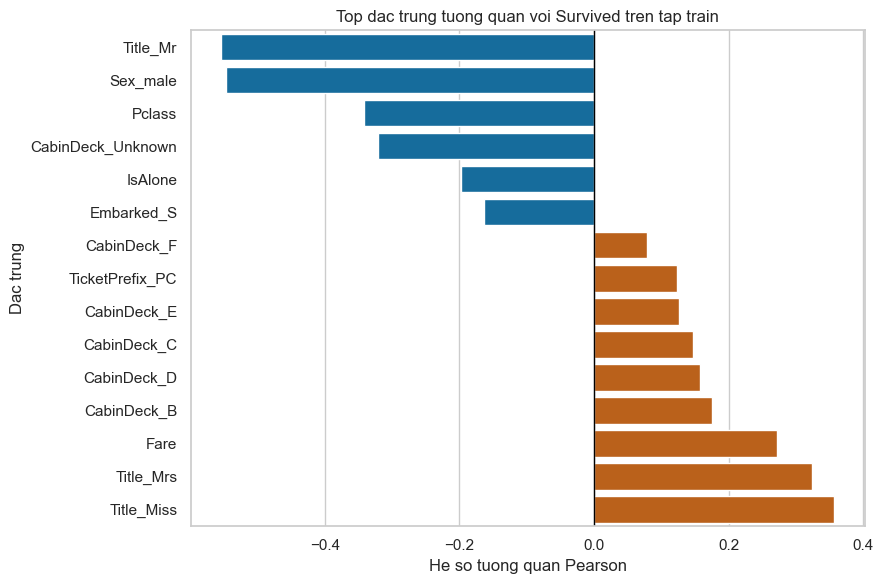

In [9]:
# Tao ban sao tu tap train da ma hoa nhung chua chuan hoa de phuc vu EDA tuong quan.
dftemp_eda = X_train_for_eda.copy()
# Gan nhan Survived vao dung index train de tinh tuong quan giua dac trung va bien muc tieu.
dftemp_eda["Survived"] = y_train

# Tinh tuong quan Pearson giua cac cot so va bien muc tieu Survived.
corr = dftemp_eda.corr(numeric_only=True)
# Lay rieng tuong quan voi Survived va bo chinh cot Survived khoi danh sach dac trung.
target_corr = corr["Survived"].drop(labels="Survived")

# Lay 15 dac trung co do tuong quan tuyet doi manh nhat de bieu do gon va de dien giai.
top_corr = target_corr.reindex(
    # Sap xep theo tri tuyet doi de giu ca tuong quan duong manh va tuong quan am manh.
    target_corr.abs().sort_values(ascending=False).head(15).index
)
# Tao bang ket qua theo do manh tuong quan de nguoi doc de theo doi.
top_corr_table = top_corr.sort_values(key=lambda s: s.abs(), ascending=False).to_frame(
    "corr_with_survived"
)

print("Top 15 thuoc tinh tuong quan manh voi Survived tren tap train:")
display(top_corr_table)

# Sap xep lai de bieu do thanh di tu tuong quan am den tuong quan duong.
plot_corr = top_corr.sort_values()
# Dung mau xanh cho tuong quan am va mau cam cho tuong quan duong de doc nhanh chieu anh huong.
colors = ["#0072B2" if value < 0 else "#D55E00" for value in plot_corr.values]

# Tao bieu do thanh ngang cho cac dac trung lien quan manh nhat den kha nang song sot.
plt.figure(figsize=(9, 6))
sns.barplot(x=plot_corr.values, y=plot_corr.index, palette=colors, hue=plot_corr.index, legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top dac trung tuong quan voi Survived tren tap train")
plt.xlabel("He so tuong quan Pearson")
plt.ylabel("Dac trung")
plt.tight_layout()
plt.show()

### Output thu được và phân tích tương quan

Bảng `top_corr_table` hiển thị các đặc trưng có tương quan Pearson mạnh nhất với `Survived`, sau khi đã lọc bỏ các cột One-Hot quá chi tiết (Name, Ticket, Cabin) để tránh nhiễu.

**Kết quả đáng chú ý:**

| Đặc trưng | Chiều tương quan | Giải thích |
|---|---|---|
| `Sex` | **Mạnh** | Giới tính là yếu tố quan trọng nhất: nữ giới sống sót nhiều hơn nam vì được ưu tiên lên xuồng cứu sinh ("women and children first") |
| `Pclass` | **Tương quan âm** | Hạng vé càng thấp (số càng lớn) thì tỷ lệ sống sót càng giảm — hành khách hạng 1 ở tầng trên, gần xuồng cứu sinh hơn |
| `Fare` | **Tương quan dương** | Giá vé cao thường gắn với hạng vé tốt hơn, nên liên quan đến tỷ lệ sống sót cao hơn |
| `Age` | Yếu | Tuổi có ảnh hưởng nhưng không mạnh bằng Sex và Pclass. Trẻ em được ưu tiên nhưng không phải tất cả |
| `SibSp`, `Parch` | Rất yếu | Số người thân đi cùng có ít tương quan tuyến tính với sống sót, nhưng vẫn có thể hữu ích khi kết hợp với các biến khác |

**Biểu đồ thanh:**
Thanh nằm bên phải trục 0 = tương quan dương (giá trị tăng thì khả năng sống sót tăng); bên trái = tương quan âm.
**Lưu ý:** Pearson chỉ đo quan hệ tuyến tính. Có thể tồn tại quan hệ phi tuyến (ví dụ: tuổi rất nhỏ HOẶC rất lớn đều có tỷ lệ sống sót khác) mà Pearson không phát hiện được. Đó là lý do ta dùng cả Random Forest (mô hình phi tuyến) chứ không chỉ Logistic Regression.


<a id="muc-10"></a>
## 10. Huấn luyện, cross-validation và tuning mô hình Logistic Regression

Phần này gộp quy trình **Stratified K-Fold cross-validation**, **tuning siêu tham số** và **đánh giá cuối** của Logistic Regression. `GridSearchCV` chỉ fit trên tập train; tập validation được giữ độc lập để đánh giá mô hình sau khi chọn tham số.


Ket qua tuning Logistic Regression bang Stratified 5-Fold Cross-Validation:


,Model,Best CV F1,Best Params
0,Logistic Regression,0.764404,"{'C': 1, 'class_weight': None}"


=== Tuned Logistic Regression ===
Best params: {'C': 1, 'class_weight': None}
Accuracy: 0.8202247191011236

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.76      0.76        68

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



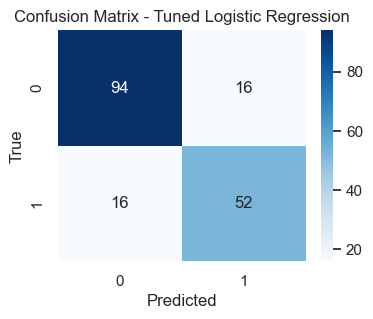

In [10]:
# Tao chien luoc Stratified K-Fold de moi fold giu ti le lop Survived gan giong du lieu goc.
cv_strategy = StratifiedKFold(
    # Dung 5 fold de danh gia on dinh hon so voi mot lan chia train/validation duy nhat.
    n_splits=5,
    # Tron du lieu truoc khi chia fold de cac fold khong phu thuoc thu tu ban dau.
    shuffle=True,
    # Co dinh random_state de ket qua cross-validation co the tai lap.
    random_state=42
)

# Khai bao luoi tham so cho Logistic Regression.
log_reg_param_grid = {
    # C dieu khien muc do regularization; C nho hon nghia la regularization manh hon.
    "C": [0.01, 0.1, 1, 10],
    # Thu them class_weight='balanced' de xu ly truong hop hai lop khong can bang hoan toan.
    "class_weight": [None, "balanced"]
}

# GridSearchCV cho Logistic Regression, toi uu F1 cua lop song sot de can bang precision va recall.
log_reg_search = GridSearchCV(
    # Khoi tao mo hinh co max_iter lon de dam bao hoi tu.
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    # Truyen luoi tham so can thu nghiem.
    param_grid=log_reg_param_grid,
    # Dung Stratified K-Fold da khai bao o tren.
    cv=cv_strategy,
    # F1 phu hop khi quan tam dong thoi precision va recall cua lop 1.
    scoring="f1",
    # Dat n_jobs=1 de output notebook sach hon va tranh canh bao multiprocessing tren Windows.
    n_jobs=1,
    # Tra ve diem train de so sanh nhanh dau hieu overfitting.
    return_train_score=True
)

# Thuc hien tuning Logistic Regression tren tap train da tien xu ly.
log_reg_search.fit(X_train, y_train)

# Lay mo hinh Logistic Regression tot nhat da duoc refit tren toan bo tap train.
log_reg = log_reg_search.best_estimator_

# Tom tat ket qua tuning cua Logistic Regression.
logistic_tuning_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Best CV F1": [log_reg_search.best_score_],
    "Best Params": [log_reg_search.best_params_]
})

print("Ket qua tuning Logistic Regression bang Stratified 5-Fold Cross-Validation:")
display(logistic_tuning_summary)

# Mo hinh Logistic Regression tot nhat duoc du doan tren tap validation doc lap.
y_pred_lr = log_reg.predict(X_val)

# In ten mo hinh va bo tham so tot nhat de ket qua danh gia co ngu canh ro rang.
print("=== Tuned Logistic Regression ===")
print("Best params:", log_reg_search.best_params_)
# Tinh va in Accuracy tren tap validation doc lap, khong tham gia cross-validation.
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
# In bao cao precision, recall va f1-score chi tiet cho tung lop.
print("\nClassification report:")
print(classification_report(y_val, y_pred_lr))

# Tinh ma tran nham lan giua nhan that va nhan du doan.
cm_lr = confusion_matrix(y_val, y_pred_lr)
# Tao khung hinh nho cho ma tran nham lan.
plt.figure(figsize=(4, 3))
# Ve heatmap ma tran nham lan, annot=True de hien so luong mau trong tung o.
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
# Dat tieu de bieu do.
plt.title("Confusion Matrix - Tuned Logistic Regression")
# Truc hoanh la nhan mo hinh du doan.
plt.xlabel("Predicted")
# Truc tung la nhan thuc te.
plt.ylabel("True")
# Hien thi bieu do.
plt.show()



### Output thu được và đánh giá Logistic Regression

**Kết quả cross-validation và tuning**

- `StratifiedKFold(n_splits=5)` giúp mỗi fold giữ tỷ lệ sống sót/không sống sót gần giống dữ liệu gốc, phù hợp với bài toán phân loại nhị phân.
- `GridSearchCV` thử các giá trị `C` và `class_weight`, sau đó chọn cấu hình có **F1-score trung bình tốt nhất** trên các validation folds.
- Việc tối ưu theo F1 hợp lý hơn chỉ nhìn Accuracy, vì ta quan tâm khả năng nhận diện lớp `Survived = 1` chứ không chỉ tỷ lệ đúng chung.

**Giải thích các chỉ số đánh giá:**

- **Accuracy:** Tỷ lệ dự đoán đúng trên toàn bộ tập validation.
- **Precision:** Trong các mẫu mô hình dự đoán là một lớp, có bao nhiêu mẫu thực sự thuộc lớp đó.
- **Recall:** Trong các mẫu thực sự thuộc một lớp, mô hình tìm đúng được bao nhiêu.
- **F1-score:** Trung bình điều hòa của Precision và Recall, phù hợp khi cần cân bằng giữa dự đoán đúng và không bỏ sót.

**Nhận xét:** Logistic Regression sau tuning là baseline rõ ràng và dễ diễn giải. Mô hình thường dự đoán tốt lớp không sống sót hơn lớp sống sót, do ranh giới tuyến tính khó nắm bắt hết các tương tác như giới tính + hạng vé + tuổi. Vì vậy cần so sánh thêm với Random Forest.


<a id="muc-11"></a>
## 11. Huấn luyện, cross-validation và tuning mô hình Random Forest Classifier

Phần này gộp **tuning siêu tham số**, **Stratified K-Fold cross-validation** và **đánh giá cuối** của Random Forest. Mô hình được tối ưu theo F1-score để so sánh công bằng với Logistic Regression.


Ket qua tuning bang Stratified 5-Fold Cross-Validation:


,Model,Best CV F1,Best Params
0,Logistic Regression,0.764404,"{'C': 1, 'class_weight': None}"
1,Random Forest,0.768332,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."


=== Tuned Random Forest ===
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Accuracy: 0.8146067415730337

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.74        68

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



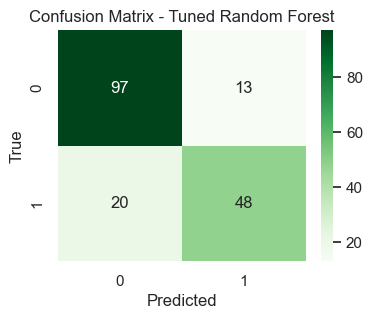

In [11]:
# Khai bao luoi tham so cho Random Forest.
rf_param_grid = {
    # So cay lon hon thuong giup du doan on dinh hon, nhung cung ton thoi gian hon.
    "n_estimators": [100, 200],
    # Thu cac do sau khac nhau de kiem soat overfitting.
    "max_depth": [None, 5, 10],
    # Tang min_samples_leaf giup cay bot hoc thuoc cac mau qua rieng le.
    "min_samples_leaf": [1, 3, 5],
    # Gioi han so dac trung moi lan tach nut de cac cay da dang hon.
    "max_features": ["sqrt", "log2"]
}

# GridSearchCV cho Random Forest voi cung chien luoc CV va scoring de so sanh cong bang.
rf_search = GridSearchCV(
    # Khoi tao Random Forest co random_state de ket qua co the tai lap.
    estimator=RandomForestClassifier(random_state=42),
    # Truyen luoi tham so da thiet ke cho Random Forest.
    param_grid=rf_param_grid,
    # Dung cung 5 fold stratified nhu Logistic Regression.
    cv=cv_strategy,
    # Toi uu F1 cua lop song sot.
    scoring="f1",
    # Dat n_jobs=1 de output notebook sach hon va tranh canh bao multiprocessing tren Windows.
    n_jobs=1,
    # Tra ve diem train de kiem tra khoang cach train/test trong CV.
    return_train_score=True
)

# Thuc hien tuning Random Forest tren cung tap train de dam bao so sanh cong bang.
rf_search.fit(X_train, y_train)

# Lay mo hinh Random Forest tot nhat da duoc refit tren toan bo tap train.
rf = rf_search.best_estimator_

# Tong hop ket qua CV tot nhat cua hai mo hinh vao mot bang ngan gon.
tuning_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Best CV F1": [log_reg_search.best_score_, rf_search.best_score_],
    "Best Params": [log_reg_search.best_params_, rf_search.best_params_]
})

print("Ket qua tuning bang Stratified 5-Fold Cross-Validation:")
display(tuning_summary)

# Mo hinh Random Forest tot nhat duoc du doan tren tap validation doc lap.
y_pred_rf = rf.predict(X_val)

# In ten mo hinh va bo tham so tot nhat de phan biet voi ban chon tham so thu cong.
print("=== Tuned Random Forest ===")
print("Best params:", rf_search.best_params_)
# Tinh va in Accuracy tren tap validation doc lap.
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
# In bao cao phan loai chi tiet.
print("\nClassification report:")
print(classification_report(y_val, y_pred_rf))

# Tinh ma tran nham lan cua Random Forest da tuning.
cm_rf = confusion_matrix(y_val, y_pred_rf)
# Tao khung hinh nho cho heatmap ma tran nham lan.
plt.figure(figsize=(4, 3))
# Ve heatmap ma tran nham lan voi tong mau xanh la.
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
# Dat tieu de bieu do.
plt.title("Confusion Matrix - Tuned Random Forest")
# Truc hoanh la nhan du doan.
plt.xlabel("Predicted")
# Truc tung la nhan that.
plt.ylabel("True")
# Hien thi bieu do.
plt.show()



### Output thu được và đánh giá Random Forest Classifier

**Kết quả cross-validation và tuning**

- Random Forest được chọn siêu tham số bằng `GridSearchCV` trên tập train, dùng cùng `StratifiedKFold` và cùng scoring `f1` như Logistic Regression.
- Các tham số được thử gồm `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`. Đây là các tham số ảnh hưởng trực tiếp đến độ phức tạp, tính ổn định và khả năng chống overfitting của rừng cây.
- Bảng `tuning_summary` cho phép so sánh **Best CV F1** của Logistic Regression và Random Forest trước khi nhìn vào validation cuối.

**Nhận xét:**

1. **Cross-validation giúp giảm phụ thuộc vào một lần chia dữ liệu:** Mỗi mô hình được đánh giá trên 5 fold khác nhau của tập train, nên kết quả tuning ổn định hơn so với chọn tham số thủ công.

2. **Validation được giữ độc lập:** Tập validation chỉ dùng sau khi `GridSearchCV` đã chọn mô hình tốt nhất. Quy trình này tránh việc vô tình tối ưu trực tiếp trên validation.

3. **Random Forest học được quan hệ phi tuyến:** So với Logistic Regression, Random Forest có lợi thế khi các yếu tố sống sót phụ thuộc vào tổ hợp đặc trưng như giới tính, hạng vé, tuổi và giá vé.

4. **Không phải lúc nào mô hình phức tạp cũng thắng rõ rệt:** Nếu Logistic Regression có validation score nhỉnh hơn, điều đó cho thấy dữ liệu Titanic nhỏ và các tín hiệu mạnh như `Sex`, `Pclass`, `Fare` đã đủ để mô hình tuyến tính làm tốt. Random Forest vẫn có giá trị vì kiểm tra được mô hình ensemble phi tuyến một cách hệ thống.

**Kết luận:** Sau khi gộp cross-validation và tuning vào quy trình huấn luyện, cả hai mô hình đều được chọn tham số công bằng bằng `GridSearchCV`. Logistic Regression là baseline dễ giải thích; Random Forest là mô hình phi tuyến để đối chiếu và kiểm tra khả năng cải thiện từ ensemble.

**Lựa chọn mô hình tốt nhất**

Dựa trên kết quả hiện tại, **Logistic Regression sau tuning được chọn làm mô hình tốt nhất để sử dụng cuối cùng cho bài toán Titanic**.

| Tiêu chí chọn mô hình | Logistic Regression | Random Forest | Mô hình tốt hơn |
|---|---:|---:|---|
| Best CV F1 | 0.7644 | **0.7683** | Random Forest nhỉnh hơn rất nhẹ |
| Accuracy trên validation | **0.8202** | 0.8146 | Logistic Regression |
| F1 lớp sống sót (`Survived = 1`) | **0.76** | 0.74 | Logistic Regression |
| Recall lớp sống sót | **0.76** | 0.71 | Logistic Regression |
| Độ đơn giản, dễ giải thích | **Cao** | Trung bình | Logistic Regression |

**Nhận xét quyết định:**

- Random Forest có **Best CV F1 = 0.7683**, nhỉnh hơn Logistic Regression rất ít (**0.7644**). Chênh lệch này quá nhỏ nên chưa đủ mạnh để ưu tiên mô hình phức tạp hơn.
- Trên tập validation độc lập, Logistic Regression lại tốt hơn: Accuracy đạt **0.8202** so với **0.8146** của Random Forest.
- Với lớp quan trọng `Survived = 1`, Logistic Regression có **F1 = 0.76** và **Recall = 0.76**, cao hơn Random Forest (**F1 = 0.74**, **Recall = 0.71**). Điều này nghĩa là Logistic Regression bỏ sót ít hành khách sống sót hơn.
- Logistic Regression cũng dễ giải thích hơn: các biến như `Sex`, `Pclass`, `Fare`, `Age` có thể được diễn giải theo chiều ảnh hưởng rõ ràng hơn so với mô hình rừng cây.

**Kết luận cuối:** Chọn **Logistic Regression đã tuning** làm mô hình cuối cùng cho bài toán Titanic. Random Forest vẫn là mô hình đối chiếu tốt, nhưng trong kết quả hiện tại chưa vượt Logistic Regression đủ rõ trên validation.

